In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Class Distributions

<BarContainer object of 2 artists>

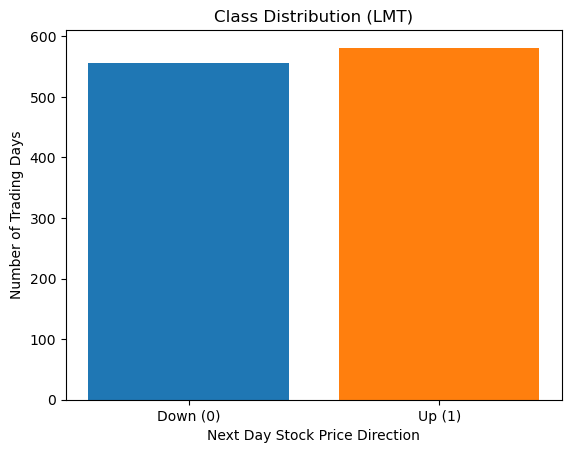

In [3]:
df = pd.read_csv("clean_data/final_data.csv")

# Count the ups and downs
counts = df["target"].value_counts().sort_index()
labels = ["Down (0)", "Up (1)"]

plt.title("Class Distribution (LMT)")
plt.ylabel("Number of Trading Days")
plt.xlabel("Next Day Stock Price Direction")
plt.bar(labels, counts.values, color=["tab:blue", "tab:orange"])

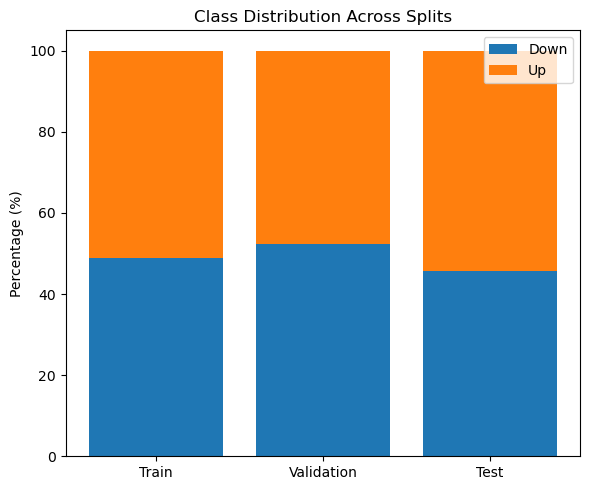

In [4]:
y_train = pd.read_csv("clean_data/y_train.csv")
y_val = pd.read_csv("clean_data/y_val.csv")
y_test = pd.read_csv("clean_data/y_test.csv")

splits = {"Train": y_train, "Validation": y_val, "Test": y_test}

down_pcts = [np.sum(y == 0)/len(y)*100 for y in splits.values()]
up_pcts   = [np.sum(y == 1)/len(y)*100 for y in splits.values()]

fig, ax = plt.subplots(figsize=(6, 5))
bars_down = ax.bar(splits.keys(), down_pcts, label="Down")
bars_up   = ax.bar(splits.keys(), up_pcts, bottom=down_pcts, label="Up")

ax.set_ylabel("Percentage (%)")
ax.set_title("Class Distribution Across Splits")
ax.legend()

plt.tight_layout()
plt.show()

## Line Plot

First split at:  2024-09-26 00:00:00
Second split at:  2025-08-07 00:00:00


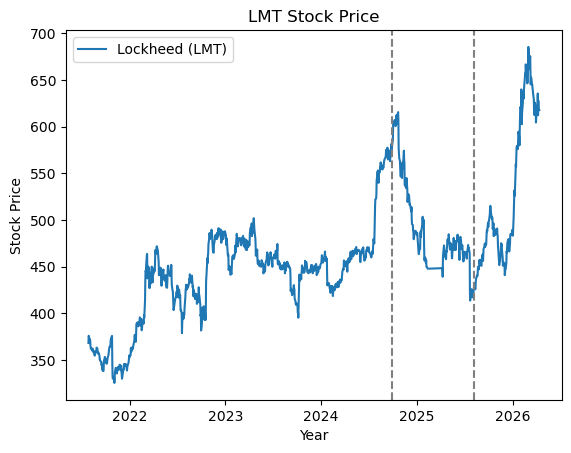

In [8]:
n = len(df)

df["date"] = pd.to_datetime(df["date"])

train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_end_date = df["date"].iloc[train_end]
val_end_date   = df["date"].iloc[val_end]

print("First split at: ", train_end_date)
print("Second split at: ", val_end_date)

plt.title("LMT Stock Price")
plt.ylabel("Stock Price")
plt.xlabel("Year")
plt.plot(df["date"], df["lmt_open"], label="Lockheed (LMT)")
#plt.plot(df["date"], df["pltr_open"], label="Palantir (PLTR)")
#plt.plot(df["date"], df["rtx_open"], label="Raytheon (RTX)")
plt.axvline(x=train_end_date, color="gray", linestyle="--")
plt.axvline(x=val_end_date, color="gray", linestyle="--")
plt.legend()